In [101]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

from tqdm.auto import tqdm
from torchmetrics.classification import MulticlassAccuracy

In [102]:
train = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    train = True,
    download = True,
    target_transform = None
)

test = datasets.FashionMNIST(
    transform = transforms.ToTensor(),
    root = "data",
    download = True,
    train = False,
    target_transform = None
)

In [103]:
len(train), len(test)

(60000, 10000)

In [104]:
train_loader = DataLoader(train, batch_size = 64, shuffle = True)
test_loader = DataLoader(test, batch_size = 64, shuffle = False)

In [105]:
image, label = next(iter(train_loader))

In [106]:
classnames = train.classes

Text(0.5, 1.0, 'Trouser')

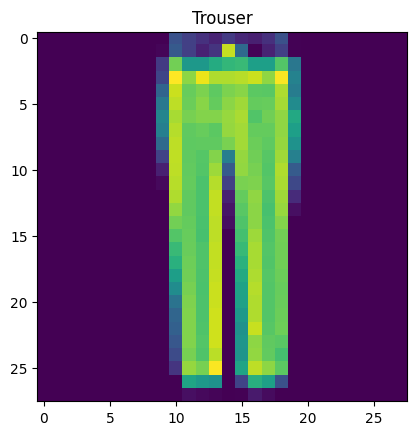

In [107]:
plt.imshow(image[0].squeeze())
plt.title(classnames[label[0]])

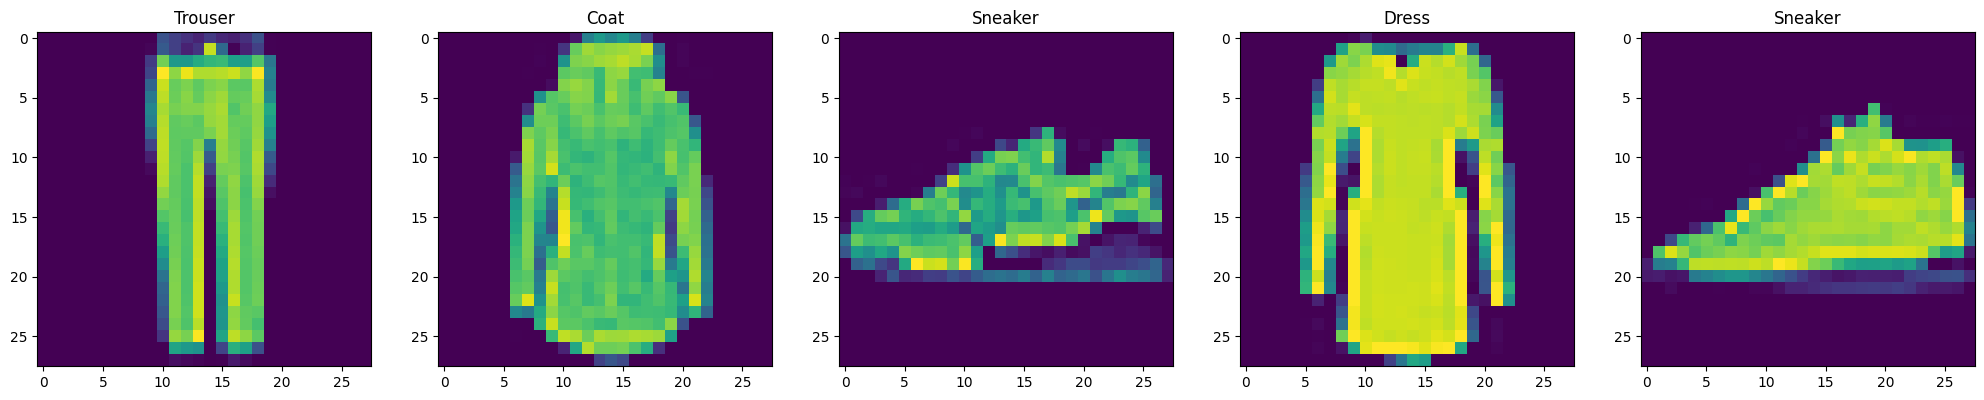

In [108]:
plt.figure(figsize = (25, 20))
for i in range(5):
    # random_idx = torch.randint(0, len(train_loader), size = (1,)).item()
    plt.subplot(1, 5, i + 1)
    plt.imshow(image[i].squeeze())
    plt.title(classnames[label[i]])

In [112]:
class FashionMNISTModel(torch.nn.Module):
    def __init__(self, in_features: int = 784, out_features: int = 10, hidden_units: int = 128, batch_units: int = 64):
        super(FashionMNISTModel, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units

        self.network = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.in_features,
                           out_features = self.hidden_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.hidden_units,
                           out_features = self.batch_units),
            torch.nn.ReLU(inplace = True),
            torch.nn.Linear(in_features = self.batch_units,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [113]:
device = "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [114]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [115]:
model = FashionMNISTModel(in_features = 784).to(device)
model

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU(inplace=True)
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [139]:
def train_model(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              accuracy_fn,
              dataset,
              device: torch.device = "cpu"
    ):

    running_loss, running_acc = 0.0, 0.0
    losses, total_accuracy = [], []

    model.train()
    accuracy_fn.reset()

    for idx, (image, target) in enumerate(dataset):
        target_logits = model(image.to(device))
        # train_accuracy = accuracy_fn.update(target, target_logits.argmax(dim = 1).to(device))

        loss = loss_fn(target_logits, target.to(device))
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        train_accuracy = accuracy_fn.update(target.to(device), target_logits.argmax(dim = 1))
        running_loss += loss.item()
        # running_acc += accuracy_fn(target.to(device), target_logits.argmax(dim = 1)).item()

    avg_running_loss = running_loss / len(dataset)
    avg_running_acc = accuracy_fn.compute().item()
    
    # losses.append(loss.item())
    # total_accuracy.append(avg_running_acc)

    # if idx % (0.1 * len(dataset)) == 0:
        # print(f"Training Loss: {avg_running_loss} | Training Accuracy: {avg_running_acc}")
    print(f"Training Loss: {avg_running_loss} | Training Accuracy: {avg_running_acc}")

    return {
        "model": model.__class__.__name__,
        "running_loss": avg_running_loss,
        "running_accuracy": avg_running_acc
        # "losses": losses,
        # "total_accuracy": total_accuracy
    }

In [148]:
def test_model(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              optimizer: torch.optim.Optimizer,
              dataset,
              accuracy_fn,
              device: torch.device = "cpu"
    ):

    running_loss, running_acc = 0.0, 0.0
    losses, total_accuracy = [], []

    accuracy_fn.reset()
    model.eval()
    with torch.inference_mode():
        for idx, (image, target) in enumerate(dataset):
            target_logits = model(image.to(device))

            loss = loss_fn(target_logits, target.to(device))
            # optimizer.zero_grad()

            # loss.backward()
            # optimizer.step()

            test_accuracy = accuracy_fn.update(target.to(device), target_logits.argmax(dim = 1))
            running_loss += loss.item()
            # running_accuracy += test_accuracy.update(target, test_accuracy)
            # running_acc += accuracy_fn(target.to(device), target_logits.argmax(dim = 1)).item()

        avg_loss = running_loss / len(dataset)
        avg_accuracy = accuracy_fn.compute().item()

        # losses.append(loss.item())
        # total_accuracy.append(accuracy_fn(target.to(device), target_logits.argmax(dim = 1)).item())

        # if idx % (0.1 * len(dataset)) == 0:
            # print(f"Testing Loss: {avg_loss} | Testing Accuracy: {avg_accuracy}")
        print(f"Testing Loss: {avg_loss} | Testing Accuracy: {avg_accuracy}\n")

        return {
            "model": model.__class__.__name__,
            "running_loss": avg_loss,
            "running_accuracy": avg_accuracy
            # "losses": losses,
            # "total_accuracy": total_accuracy
        }

In [149]:
def eval_model(model: torch.nn.Module,
              dataset,
              device
    ):
    model.train()

    with torch.inference_mode():
        for idx, (image, target) in enumerate(dataset):
            target_pred = model(image.to(device))

        return target_pred

In [142]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 1e-3, weight_decay = 1e-4)
accuracy_fn = MulticlassAccuracy(num_classes = 10).to(device)

In [143]:
torch.manual_seed(42)
torch.mps.manual_seed(42)

In [144]:
from timeit import default_timer as timer
# import torch

def calculate_time(start: float, end: float, device: torch.device | str = "cpu", label: str = "") -> float:
    total = end - start

    label_info = f" for {label}" if label else ""
    device_name = device if isinstance(device, str) else device.type

    print(f"⏱️ Time taken{label_info}: {total:.3f} seconds on device: {device_name}")

    return total

In [151]:
epochs = 30

start = timer()

losses, total_accuracy, total_epochs = [], [], []
test_losses, test_total_accuracy = [], []

for epoch in tqdm(range(epochs)):
    model0_train = train_model(model = model,
                       loss_fn = loss_fn,
                       optimizer = optimizer,
                       accuracy_fn = accuracy_fn,
                       device = device,
                       dataset = train_loader)

    losses.append(model0_train["running_loss"])
    total_accuracy.append(model0_train["running_accuracy"])

    model0_test = test_model(model = model,
                       loss_fn = loss_fn,
                       optimizer = optimizer,
                       accuracy_fn = accuracy_fn,
                       device = device,
                       dataset = test_loader)

    test_losses.append(model0_test["running_loss"])
    test_total_accuracy.append(model0_test["running_accuracy"])

    total_epochs.append(epoch)

    # if epoch % (0.1 * len(epochs)) == 0:
    #     ...

end = timer()
calculate_time(start, end, device)

  0%|                                                    | 0/10 [00:00<?, ?it/s]

Training Loss: 0.20099445256883147 | Training Accuracy: 0.9248694181442261


 10%|████▍                                       | 1/10 [00:12<01:52, 12.53s/it]

Testing Loss: 0.324996992352472 | Testing Accuracy: 0.8900580406188965

Training Loss: 0.19815017199163626 | Training Accuracy: 0.9251018762588501


 20%|████████▊                                   | 2/10 [00:17<01:03,  7.98s/it]

...

 90%|███████████████████████████████████████▌    | 9/10 [00:50<00:04,  4.90s/it]

Testing Loss: 0.3485885483159381 | Testing Accuracy: 0.8882237076759338

Training Loss: 0.17675953028378075 | Training Accuracy: 0.9337096810340881


100%|███████████████████████████████████████████| 10/10 [00:57<00:00,  5.80s/it]

Testing Loss: 0.34618156626939206 | Testing Accuracy: 0.8900067806243896

⏱️ Time taken: 57.999 seconds on device: mps


57.998726499965414

In [157]:
df = pd.DataFrame([total_epochs, losses, total_accuracy])
df

,0,1,2,3,4,5,6,7,8,9
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.00000
1,0.200994,0.198150,0.195944,0.191708,0.189254,0.185077,0.184615,0.180980,0.179160,0.17676
2,0.924869,0.925102,0.925912,0.926571,0.929144,0.929451,0.930518,0.931528,0.933025,0.93371


In [77]:
class FashionMNISTModelV1(torch.nn.Module):
    def __init__(self, in_features: int = None, out_features: int = None, hidden_units: int = None, batch_units: int = None):
        super(FashionMNISTModelV1, self).__init__()
        self.in_features: int = in_features
        self.out_features: int = out_features
        self.hidden_units: int = hidden_units
        self.batch_units: int = batch_units

        self.convolutional_layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        self.convolutional_layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = 3,
                           padding = 1,
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = 2,
                              stride = 2)
        )
        self.linear_layer = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.hidden_units*7*7,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutional_layer1(x)
        # print(x.shape)
        x = self.convolutional_layer2(x)
        # print(x.shape)
        x = self.linear_layer(x)
        
        # print(x.shape)
        return x

In [78]:
model1 = FashionMNISTModelV1(in_features = 1, out_features = len(classnames), hidden_units = 32).to(device)
model1

FashionMNISTModelV1(
  (convolutional_layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=10, bias=True)
  )
)

In [79]:
# model1.eval()

# with torch.inference_mode():
#     for image, target in test_loader:
#         target_prediction = model1(image.to(device))

# target_prediction

In [80]:
dummy_target = torch.randn(size = (64, 28, 28))
# dummy_target

In [81]:
model.eval()
with torch.inference_mode():
    target_prediction = model(dummy_target.to(device))

# target_prediction

In [82]:
image.shape

torch.Size([64, 1, 28, 28])

In [83]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model1.parameters(), lr = 1e-3, weight_decay = 1e-5)

In [84]:
start = timer()

for epoch in tqdm(range(10)):
    train = train_model(model = model1,
               loss_fn = loss_fn,
               optimizer = optimizer,
               dataset = train_loader,
               device = device,
               accuracy_fn = accuracy_fn
    )

    test = test_model(model = model1,
               loss_fn = loss_fn,
               optimizer = optimizer,
               dataset = test_loader,
               device = device,
               accuracy_fn = accuracy_fn
    )

end = timer()

calculate_time(start, end, device)

  0%|                                                    | 0/10 [00:00<?, ?it/s]

Training Loss: 0.46105824709574045 | Training Accuracy: 0.8327934741973877


 10%|████▍                                       | 1/10 [00:24<03:44, 24.95s/it]

Testing Loss: 0.321478776301548 | Testing Accuracy: 0.885346531867981

Training Loss: 0.2872377663199454 | Training Accuracy: 0.8964105844497681


 20%|████████▊                                   | 2/10 [00:31<01:54, 14.37s/it]

...

 90%|███████████████████████████████████████▌    | 9/10 [02:43<00:17, 17.71s/it]

Testing Loss: 0.23938469527063855 | Testing Accuracy: 0.9193426370620728

Training Loss: 0.13951134022031383 | Training Accuracy: 0.9490050673484802


100%|███████████████████████████████████████████| 10/10 [03:10<00:00, 19.03s/it]

Testing Loss: 0.2287386739567207 | Testing Accuracy: 0.9200484156608582

⏱️ Time taken: 190.319 seconds on device: mps


190.31859679101035

In [94]:
train

{'running_loss': 0.13951134022031383,
 'running_accuracy': 0.9490050673484802,
 'losses': [0.13951134022031383],
 'total_accuracy': [0.9490050673484802]}

In [95]:
for loss in train["losses"]:
    print(loss)

0.13951134022031383
